In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             ConfusionMatrixDisplay)

In [43]:
columns = [
    'id','diagnosis',
    'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
    'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
    'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
    'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
    'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
    'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

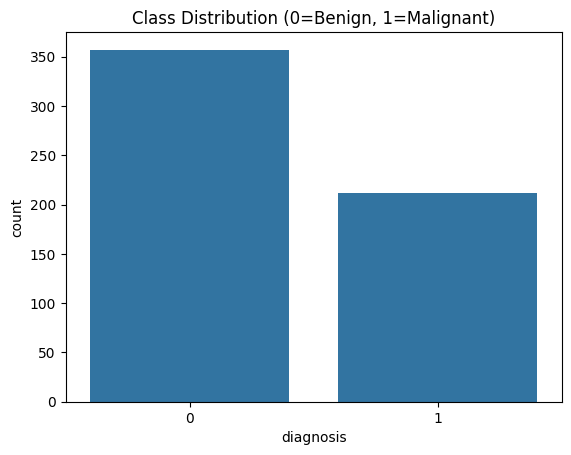

In [44]:
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution (0=Benign, 1=Malignant)")
plt.show()

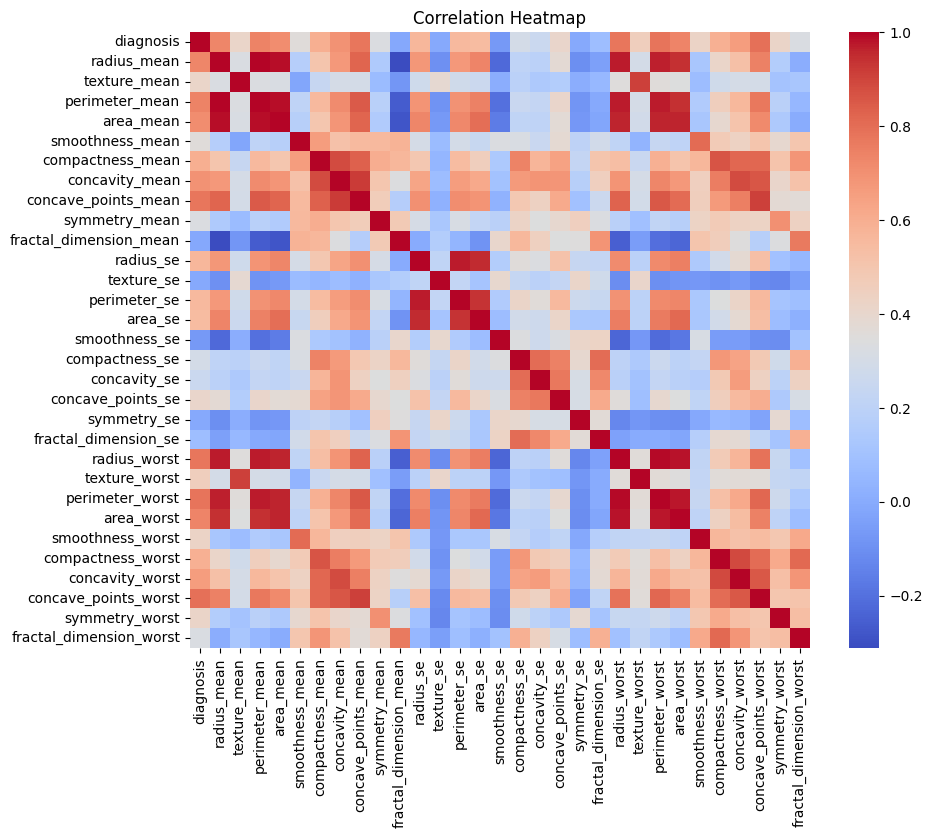

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

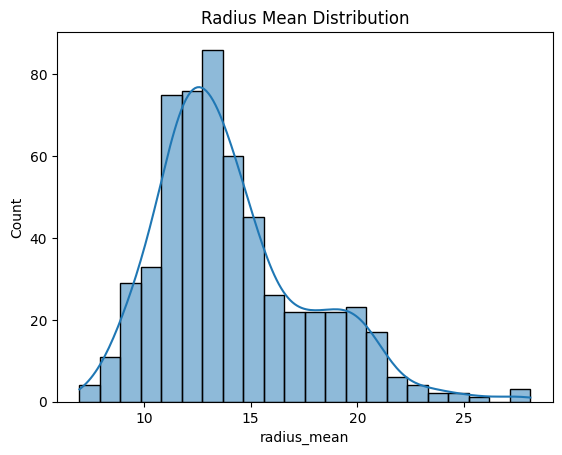

In [46]:
sns.histplot(df['radius_mean'], kde=True)
plt.title("Radius Mean Distribution")
plt.show()

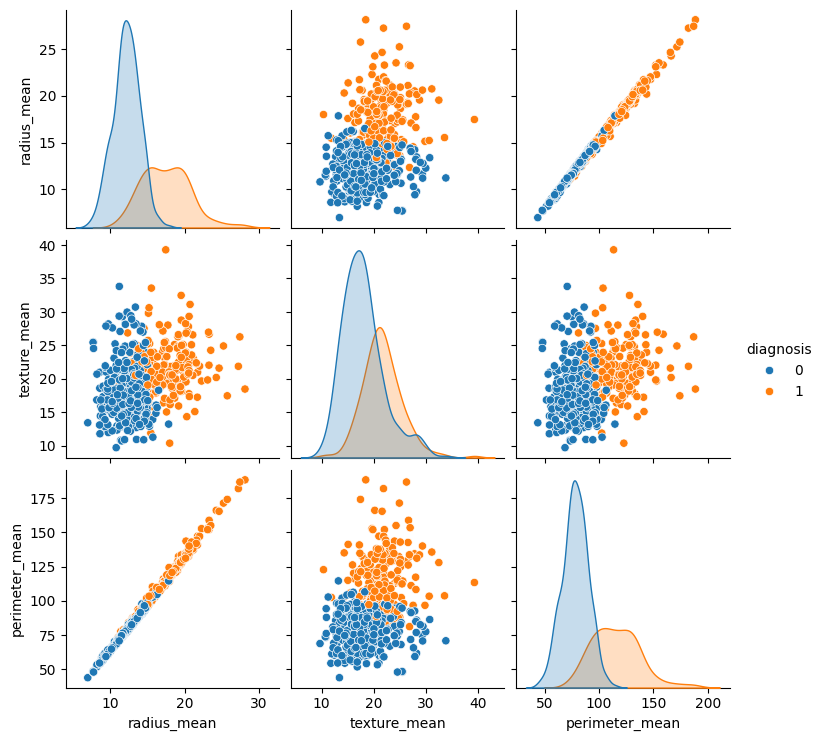

In [47]:
sns.pairplot(
    df[['radius_mean','texture_mean','perimeter_mean','diagnosis']],
    hue='diagnosis'
)
plt.show()

In [48]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

In [51]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [52]:
y_pred_custom = (y_prob > 0.3).astype(int)

print("=== Default Threshold (0.5) ===")
print(classification_report(y_test, y_pred))

print("=== Custom Threshold (0.3) ===")
print(classification_report(y_test, y_pred_custom))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

=== Custom Threshold (0.3) ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.96        71
           1       0.91      0.98      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96

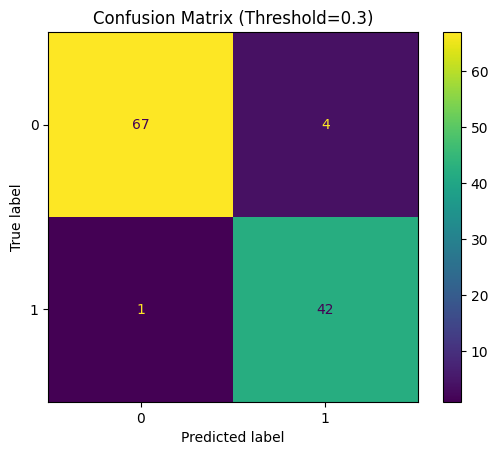

In [53]:
cm = confusion_matrix(y_test, y_pred_custom)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Threshold=0.3)")
plt.show()

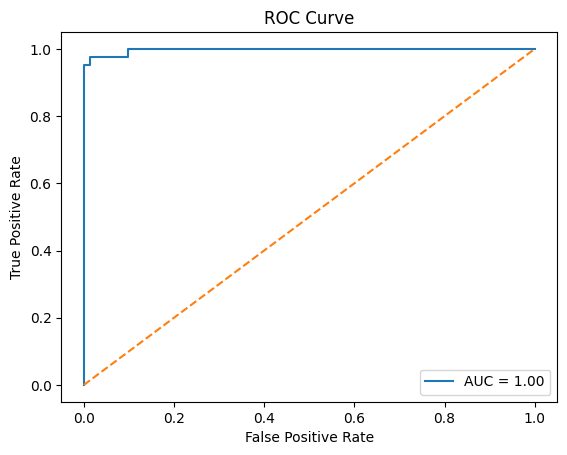

In [54]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

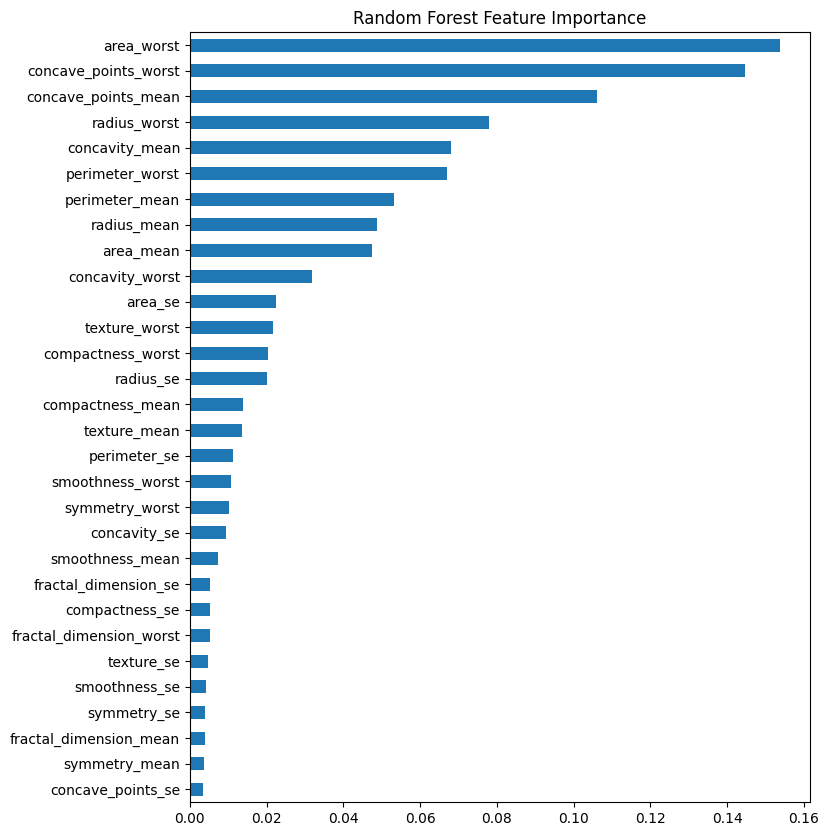

In [55]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

importances.sort_values().plot(kind='barh', figsize=(8,10))
plt.title("Random Forest Feature Importance")
plt.show()

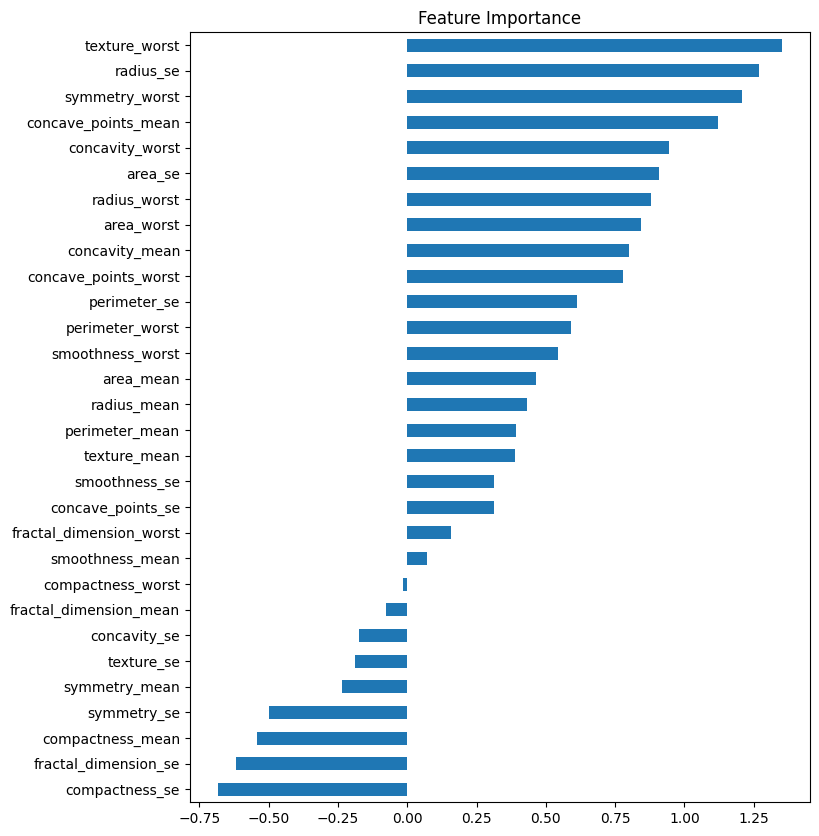

In [56]:
coefficients = pd.Series(lr.coef_[0], index=X.columns)

coefficients.sort_values().plot(kind='barh', figsize=(8,10))
plt.title("Feature Importance")
plt.show()

In [57]:
cv_scores = cross_val_score(lr, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Mean CV Accuracy: 0.9507995652848935
